# Notebook 02: Transformation

> **KDD Step 3**: Transformation
> Split truoc -> Encode -> Scenario A/B -> Ablation Study

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
DATA_DIR = "data"
REPORT_DIR = "report"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: /home/thacbao/Documents/project/kpdl


## 1. Load raw data & Clean

In [2]:
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")
n_raw = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_clean = len(df)
print("Raw:", n_raw, "-> Cleaned:", n_clean, "(removed", n_raw - n_clean, "duplicates)")

Raw: 41188 -> Cleaned: 41176 (removed 12 duplicates)


## 2. Train/Test Split — TRUOC moi transformation

> Encoder/imputer chi fit tren train. Test chi transform.
> Decision Tree KHONG can scaling.

In [3]:
X = df.drop(columns=["y"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", len(X_train), "| Test:", len(X_test))
print()
print("Train y distribution:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Test y distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train: 32940 | Test: 8236

Train y distribution:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64

Test y distribution:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


## 3. Encoding — fit tren train, transform test

In [4]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns (" + str(len(cat_cols)) + "):", cat_cols)
print("Numerical columns (" + str(len(num_cols)) + "):", num_cols)

# Fit encoder CHI tren train
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop=None)
enc.fit(X_train[cat_cols])

# Transform train va test
train_cat_enc = pd.DataFrame(
    enc.transform(X_train[cat_cols]),
    columns=enc.get_feature_names_out(),
    index=X_train.index
)
test_cat_enc = pd.DataFrame(
    enc.transform(X_test[cat_cols]),
    columns=enc.get_feature_names_out(),
    index=X_test.index
)

X_train_final = pd.concat([X_train[num_cols].reset_index(drop=True),
                           train_cat_enc.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test[num_cols].reset_index(drop=True),
                          test_cat_enc.reset_index(drop=True)], axis=1)

print("\nSau encoding:", X_train_final.shape[1], "features")
print("Train:", X_train_final.shape, "| Test:", X_test_final.shape)

Categorical columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']



Sau encoding: 63 features
Train: (32940, 63) | Test: (8236, 63)


## 4. Scenario A/B

| Scenario | Duration | Muc dich |
|---|---|---|
| **A: Benchmark** | Co | So sanh thuat toan |
| **B: Realistic** | Khong | Mo hinh thuc te |

In [5]:
dur_cols = [c for c in X_train_final.columns if "duration" in c.lower()]
print("Duration columns:", dur_cols)

# Scenario A: Benchmark (co duration)
data_A = {
    "X_train": X_train_final.values,
    "X_test": X_test_final.values,
    "y_train": y_train.values,
    "y_test": y_test.values,
    "feature_names": X_train_final.columns.tolist(),
}

# Scenario B: Realistic (khong duration)
X_train_B = X_train_final.drop(columns=dur_cols)
X_test_B = X_test_final.drop(columns=dur_cols)

data_B = {
    "X_train": X_train_B.values,
    "X_test": X_test_B.values,
    "y_train": y_train.values,
    "y_test": y_test.values,
    "feature_names": X_train_B.columns.tolist(),
}

print("Scenario A features:", len(data_A['feature_names']))
print("Scenario B features:", len(data_B['feature_names']))

Duration columns: ['duration']


Scenario A features: 63
Scenario B features: 62


## 5. Ablation Study

> B+ (Undersampling) la thi nghiem BO SUNG, khong phai scenario chinh.

In [6]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(data_B["X_train"], data_B["y_train"])

scenarios = {
    "A: Benchmark (co duration)": (data_A["X_train"], data_A["y_train"],
                                    data_A["X_test"], data_A["y_test"]),
    "B: Realistic (khong duration)": (data_B["X_train"], data_B["y_train"],
                                       data_B["X_test"], data_B["y_test"]),
    "B+ [bo sung]: No dur + Undersample": (X_train_us, y_train_us,
                                            data_B["X_test"], data_B["y_test"]),
}

print("=" * 85)
print("  ABLATION: TAC DONG CUA TRANSFORMATION LEN MODEL")
print("=" * 85)
header = "Scenario".ljust(42) + "Train".rjust(7) + "Feat".rjust(5) + "Acc".rjust(8) + "Prec".rjust(8) + "Rec".rjust(8) + "F1".rjust(8)
print(header)
print("-" * 85)

ablation_results = {}
for name, (Xtr, ytr, Xte, yte) in scenarios.items():
    dt = SkDT(criterion="gini", max_depth=5, random_state=42)
    dt.fit(Xtr, ytr)
    yp = dt.predict(Xte)
    acc = accuracy_score(yte, yp)
    prec = precision_score(yte, yp, pos_label="yes")
    rec = recall_score(yte, yp, pos_label="yes")
    f1 = f1_score(yte, yp, pos_label="yes")
    row = name.ljust(42) + str(len(ytr)).rjust(7) + str(Xtr.shape[1]).rjust(5)
    row += ("%.4f" % acc).rjust(8) + ("%.4f" % prec).rjust(8)
    row += ("%.4f" % rec).rjust(8) + ("%.4f" % f1).rjust(8)
    print(row)
    ablation_results[name] = {"acc": acc, "prec": prec, "rec": rec, "f1": f1}

print("-" * 85)
print()
print("KET LUAN ABLATION:")
print("  1. Duration tang accuracy/F1 nhung prediction-time unavailable")
print("  2. Loai duration -> metric giam -> phan anh thuc te hon")
print("  3. Undersampling tang Recall nhung giam Precision -> trade-off")

  ABLATION: TAC DONG CUA TRANSFORMATION LEN MODEL
Scenario                                    Train Feat     Acc    Prec     Rec      F1
-------------------------------------------------------------------------------------
A: Benchmark (co duration)                  32940   63  0.9144  0.6538  0.5108  0.5735


B: Realistic (khong duration)               32940   62  0.9009  0.6522  0.2586  0.3704
B+ [bo sung]: No dur + Undersample           7422   62  0.8719  0.4480  0.5894  0.5091
-------------------------------------------------------------------------------------

KET LUAN ABLATION:
  1. Duration tang accuracy/F1 nhung prediction-time unavailable
  2. Loai duration -> metric giam -> phan anh thuc te hon
  3. Undersampling tang Recall nhung giam Precision -> trade-off


## 6. Ablation Visualization

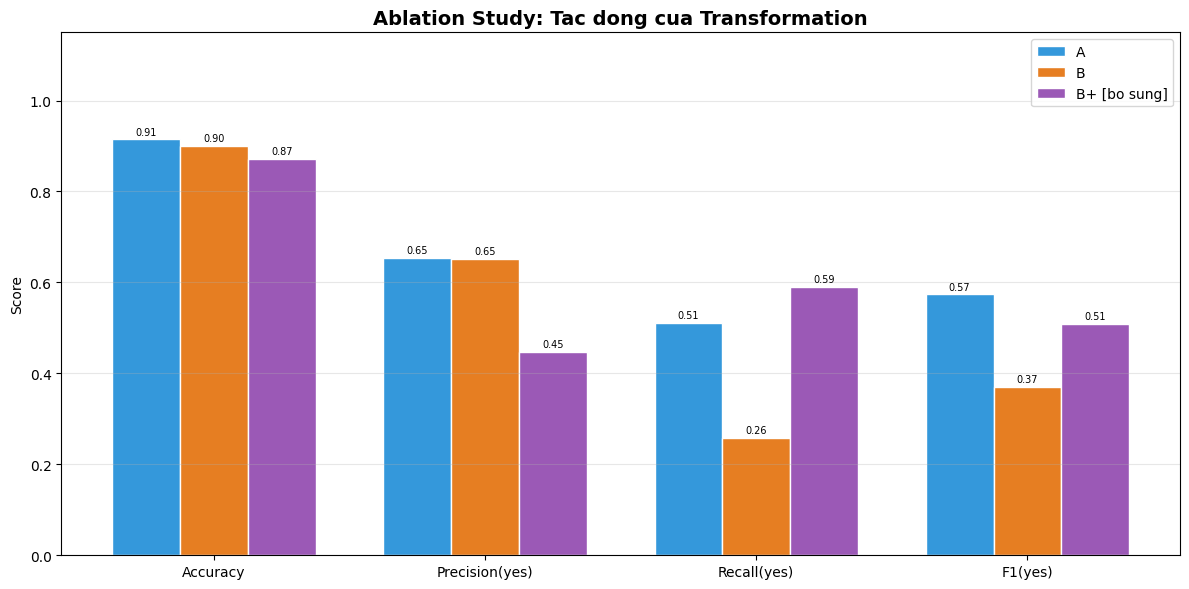

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ["acc", "prec", "rec", "f1"]
metric_labels = ["Accuracy", "Precision(yes)", "Recall(yes)", "F1(yes)"]
x = np.arange(len(metrics))
width = 0.25
names = list(ablation_results.keys())
colors_bar = ["#3498db", "#e67e22", "#9b59b6"]

for i, name in enumerate(names):
    vals = [ablation_results[name][m] for m in metrics]
    short = name.split(":")[0]
    bars = ax.bar(x + i * width, vals, width, label=short, color=colors_bar[i], edgecolor="white")
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Ablation Study: Tac dong cua Transformation", fontweight="bold", fontsize=14)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR + "/02_ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Luu processed data

In [8]:
save_data = {
    "scenario_A": data_A,
    "scenario_B": data_B,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "encoder": enc,
    "n_raw": n_raw,
    "n_clean": n_clean,
}

with open(DATA_DIR + "/processed_data.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("Saved: data/processed_data.pkl")
print("  Scenario A:", data_A['X_train'].shape[0], "train x", data_A['X_train'].shape[1], "features")
print("  Scenario B:", data_B['X_train'].shape[0], "train x", data_B['X_train'].shape[1], "features")

# Luu raw split cho CV (Pipeline per fold)
save_raw = {
    "X_train_raw": X_train,
    "X_test_raw": X_test,
    "y_train": y_train.values,
    "y_test": y_test.values,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
}
with open(DATA_DIR + "/raw_split.pkl", "wb") as f:
    pickle.dump(save_raw, f)

print("Saved: data/raw_split.pkl")

Saved: data/processed_data.pkl
  Scenario A: 32940 train x 63 features
  Scenario B: 32940 train x 62 features
Saved: data/raw_split.pkl


## 8. Tong ket NB02

| Chi so | Gia tri |
|---|---|
| Train/Test split | 80/20 stratified |
| Encoding | One-Hot (fit on train only) |
| Scaling | Khong (DT khong can) |
| Scenario A | Co duration, benchmark |
| Scenario B | Khong duration, realistic |
| B+ (ablation only) | Undersampling, thi nghiem bo sung |